# Rice Leaf Disease Classification using Baseline CNN

### Original Baseline CNN architecture 

In [4]:
!pip install tensorflow matplotlib scikit-learn

## Import Required Libraries

The required libraries are imported for:
- Deep learning
- Image processing
- Visualization
- Model evaluation

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
NumPy: 2.0.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Dataset Path

The dataset contains separate training and validation directories.

The original notebook contains:

- Training images: 2100
- Validation images: 528
- Number of classes: 6
- Image size: 224 × 224

In [6]:
dataset_path = (
    "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease"
)

original_train_dir = os.path.join(
    dataset_path,
    "train"
)

original_val_dir = os.path.join(
    dataset_path,
    "validation"
)

print("Dataset :", dataset_path)
print("Train   :", original_train_dir)
print("Val     :", original_val_dir)

print("\nDirectories exist:")
print("Dataset :", os.path.isdir(dataset_path))
print("Train   :", os.path.isdir(original_train_dir))
print("Val     :", os.path.isdir(original_val_dir))

Dataset : /kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease
Train   : /kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/train
Val     : /kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation

Directories exist:
Dataset : True
Train   : True
Val     : True


In [27]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    original_train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    original_val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nClass Names:", class_names)
print("Number of Classes:", num_classes)

Found 2100 files belonging to 6 classes.
Found 528 files belonging to 6 classes.

Class Names: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']
Number of Classes: 6


##  Dataset Performance Optimization

Caching and prefetching are used to improve the input pipeline.

The validation dataset is not shuffled because fixed ordering is useful during
evaluation and confusion-matrix generation.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000, seed=42)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print("Dataset pipeline ready.")

Dataset pipeline ready.


## Inspect Dataset

A batch of training images is displayed to verify the image dimensions and class labels.

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


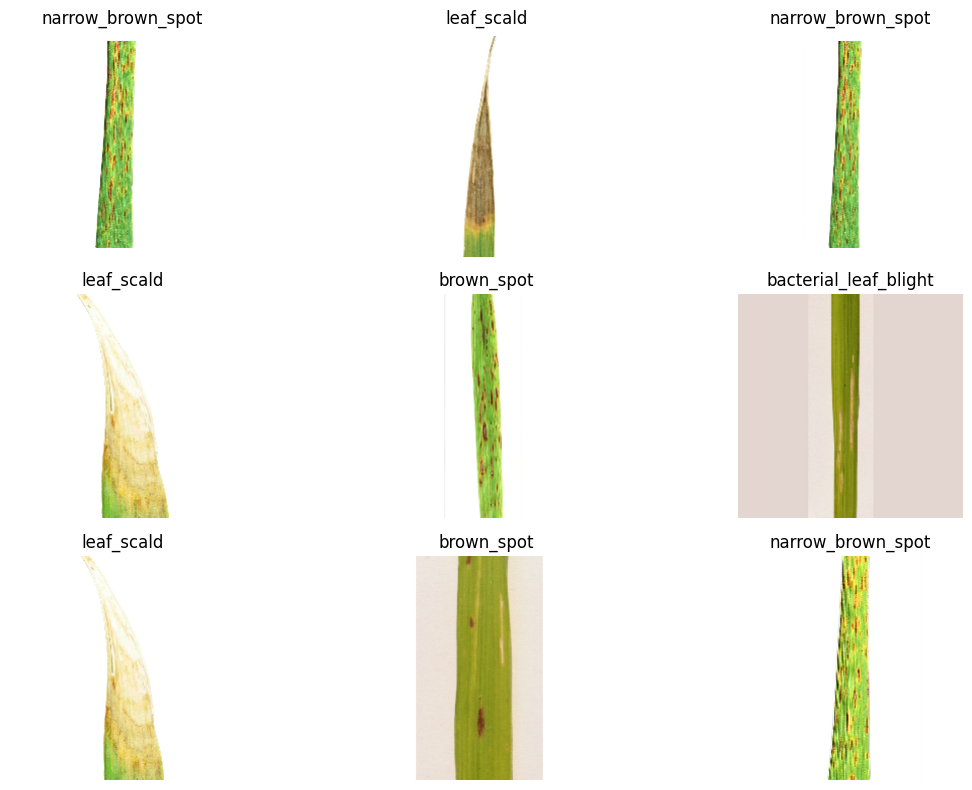

In [9]:
for images, labels in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    plt.figure(figsize=(12, 8))

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i].numpy()]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

##  Aggressive Data Augmentation

To improve generalization, stronger augmentation is applied during training.

The augmentation pipeline contains more than six transformations:

1. Horizontal and vertical flipping
2. Rotation
3. Zoom
4. Translation
5. Contrast adjustment
6. Brightness adjustment
7. Gaussian noise

Augmentation is applied only during training.
Validation images remain unchanged.

In [10]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            mode="horizontal_and_vertical",
            seed=42
        ),

        layers.RandomRotation(
            factor=0.20,
            fill_mode="reflect",
            seed=42
        ),

        layers.RandomZoom(
            height_factor=(-0.15, 0.20),
            width_factor=(-0.15, 0.20),
            fill_mode="reflect",
            seed=42
        ),

        layers.RandomTranslation(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="reflect",
            seed=42
        ),

        layers.RandomContrast(
            factor=0.20,
            seed=42
        ),

        layers.RandomBrightness(
            factor=0.15,
            value_range=(0, 1),
            seed=42
        ),

        layers.GaussianNoise(
            stddev=0.02
        )
    ],
    name="aggressive_augmentation"
)

print("Aggressive augmentation ready.")

Aggressive augmentation ready.


## Image Normalization

Pixel values are converted from the 0–255 range to the 0–1 range.

Normalization is performed before augmentation so that brightness and noise transformations operate on the same scale.

In [11]:
normalization = layers.Rescaling(
    1.0 / 255.0
)

print("Normalization layer ready.")

Normalization layer ready.


## Visualize Augmented Images

Augmented images are visualized to ensure that the transformations preserve
the important structure of the rice leaf.

Original batch shape: (32, 224, 224, 3)
Normalized batch shape: (9, 224, 224, 3)
Augmented batch shape: (9, 224, 224, 3)


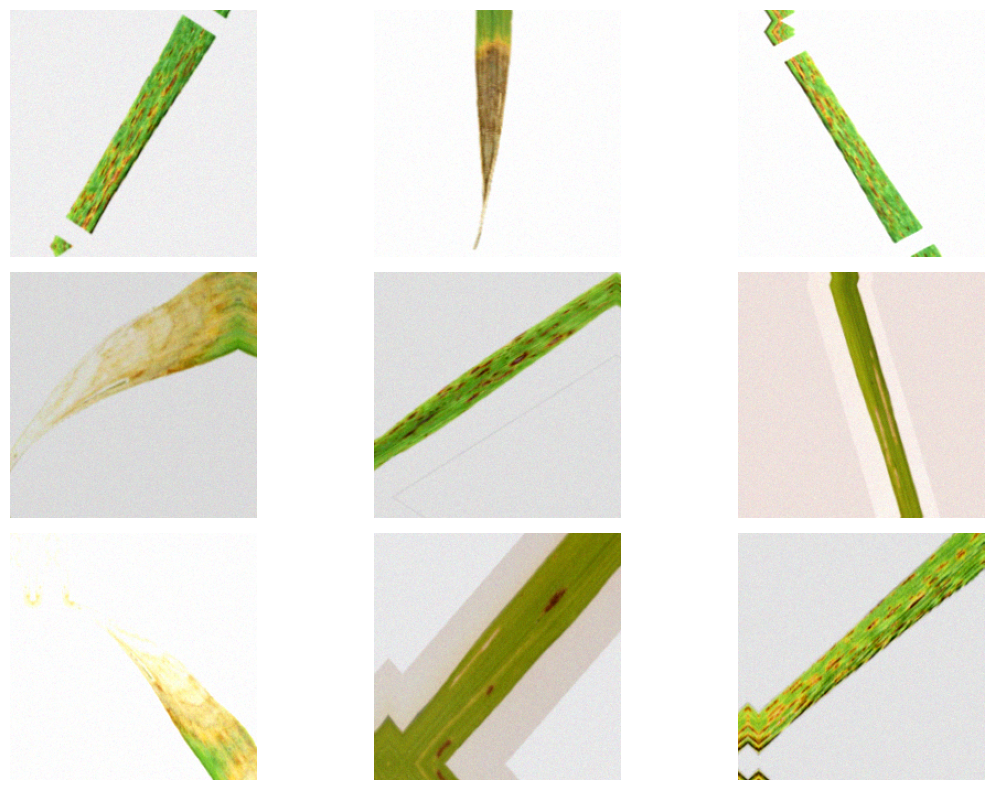

In [12]:
for images, labels in train_ds.take(1):

    normalized_images = normalization(
        images[:9]
    )

    augmented_images = data_augmentation(
        normalized_images,
        training=True
    )

    print(
        "Original batch shape:",
        images.shape
    )

    print(
        "Normalized batch shape:",
        normalized_images.shape
    )

    print(
        "Augmented batch shape:",
        augmented_images.shape
    )

    plt.figure(figsize=(12, 8))

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.clip_by_value(
                augmented_images[i],
                0,
                1
            )
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Baseline CNN Architecture

The custom CNN is trained from scratch.

The architecture contains convolutional blocks followed by max pooling and fully connected layers.

The final softmax layer produces the probability for each disease class.

In [13]:
model = Sequential(
    [
        layers.Input(
            shape=(224, 224, 3)
        ),

        normalization,

        data_augmentation,

        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dropout(
            0.5
        ),

        layers.Dense(
            num_classes,
            activation="softmax"
        )
    ],
    name="Rice_Leaf_Baseline_CNN"
)

model.summary()

Model: "Rice_Leaf_Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aggressive_augmentation         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,206 (49.36 MB)

 Trainable params: 12,939,206 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The Adam optimizer is used with an initial learning rate of 0.001.

Sparse categorical crossentropy is used for multi-class classification with integer labels.

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


##  Compile Baseline CNN

Adam optimizer is used with an initial learning rate of 0.001.

Sparse categorical cross-entropy is used because the labels are integer class
indices.

In [15]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


##  Training Callback

ReduceLROnPlateau decreases the learning rate when validation performance
stops improving.

ModelCheckpoint saves the best model.

In [16]:
checkpoint_path = (
    "/kaggle/working/"
    "best_baseline_cnn.keras"
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    reduce_lr
]

print("Callbacks ready.")

Callbacks ready.


#  Stage 1 — Train Baseline CNN


In [17]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2007 - loss: 2.6161
Epoch 1: val_accuracy improved from None to 0.32955, saving model to /kaggle/working/best_baseline_cnn.keras

Epoch 1: finished saving model to /kaggle/working/best_baseline_cnn.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.2386 - loss: 1.9910 - val_accuracy: 0.3295 - val_loss: 1.6510 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3356 - loss: 1.6161
Epoch 2: val_accuracy improved from 0.32955 to 0.46023, saving model to /kaggle/working/best_baseline_cnn.keras

Epoch 2: finished saving model to /kaggle/working/best_baseline_cnn.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.3667 - loss: 1.5549 - val_accuracy: 0.4602 - val_loss: 1.3582 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4675 - loss: 1.3532
Epoch 3: val_accuracy improved from 0.46023 to 0.53409, saving model to /kaggle/working/best

## Baseline Training Accuracy

Training and validation accuracy are visualized to evaluate the learning behavior of the CNN.

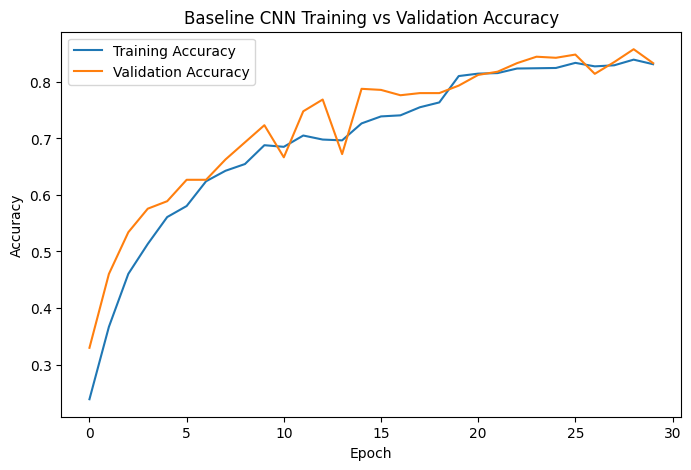

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stage1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_stage1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

## Baseline Training Loss

Training and validation loss are visualized to identify convergence and possible overfitting.

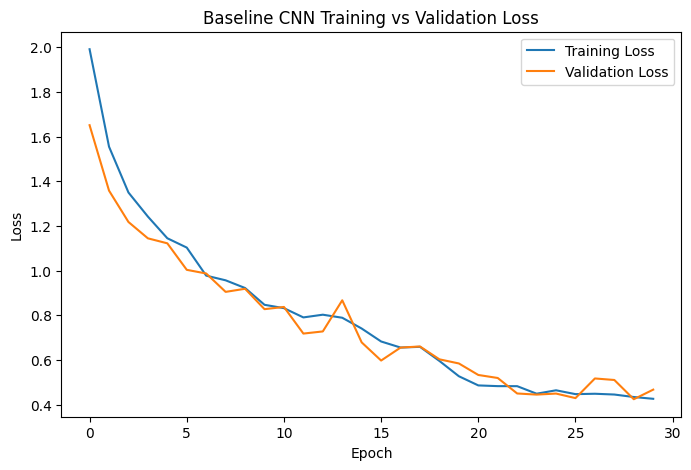

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stage1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_stage1.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Training vs Validation Loss")
plt.legend()
plt.show()

#  Low-Learning-Rate Fine-Tuning

The baseline CNN does not contain a pretrained backbone, therefore classical
transfer-learning fine-tuning is not applicable.

Instead, the already-trained CNN is continued with a much smaller learning
rate.

This allows the learned weights to make smaller updates and refine the
decision boundaries without changing the architecture.

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print(
    "Fine-tuning learning rate: 0.00001"
)

Fine-tuning learning rate: 0.00001


In [28]:
fine_tune_checkpoint = (
    "/kaggle/working/"
    "best_baseline_cnn_finetuned.keras"
)

fine_tune_checkpoint_callback = ModelCheckpoint(
    fine_tune_checkpoint,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

fine_tune_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

fine_tune_callbacks = [
    fine_tune_checkpoint_callback,
    fine_tune_reduce_lr
]

## Fine-Tuning Training

Early stopping remains OFF.

The model will run the complete 25 epochs unless another system-level issue
interrupts the training.

In [24]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=fine_tune_callbacks,
    verbose=1
)

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8536 - loss: 0.3800
Epoch 1: val_accuracy improved from None to 0.84848, saving model to /kaggle/working/best_baseline_cnn_finetuned.keras

Epoch 1: finished saving model to /kaggle/working/best_baseline_cnn_finetuned.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8495 - loss: 0.3880 - val_accuracy: 0.8485 - val_loss: 0.4407 - learning_rate: 1.0000e-05
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8505 - loss: 0.3825
Epoch 2: val_accuracy improved from 0.84848 to 0.85795, saving model to /kaggle/working/best_baseline_cnn_finetuned.keras

Epoch 2: finished saving model to /kaggle/working/best_baseline_cnn_finetuned.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8476 - loss: 0.3961 - val_accuracy: 0.8580 - val_loss: 0.4224 - learning_rate: 1.0000e-05
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8598 - loss: 0.4075
Epoch 3: val_accuracy did not improve from 0.8

# Final Model Evaluation

The final fine-tuned CNN is evaluated on the validation dataset.

In [25]:
final_loss, final_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(
    f"Final Validation Loss: {final_loss:.4f}"
)

print(
    f"Final Validation Accuracy: "
    f"{final_accuracy * 100:.2f}%"
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8598 - loss: 0.4210
Final Validation Loss: 0.4210
Final Validation Accuracy: 85.98%


## Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

for every rice leaf disease class.

In [26]:
true_labels = np.concatenate([
    labels.numpy()
    for images, labels in val_ds
])

predictions = model.predict(
    val_ds,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(
    classification_report(
        true_labels,
        predicted_classes,
        target_names=class_names,
        digits=4
    )
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
                       precision    recall  f1-score   support

bacterial_leaf_blight     0.8485    0.9545    0.8984        88
           brown_spot     0.7245    0.8068    0.7634        88
              healthy     0.9600    0.8182    0.8834        88
           leaf_blast     0.7750    0.7045    0.7381        88
           leaf_scald     0.9878    0.9205    0.9529        88
    narrow_brown_spot     0.8936    0.9545    0.9231        88

             accuracy                         0.8598       528
            macro avg     0.8649    0.8598    0.8599       528
         weighted avg     0.8649    0.8598    0.8599       528



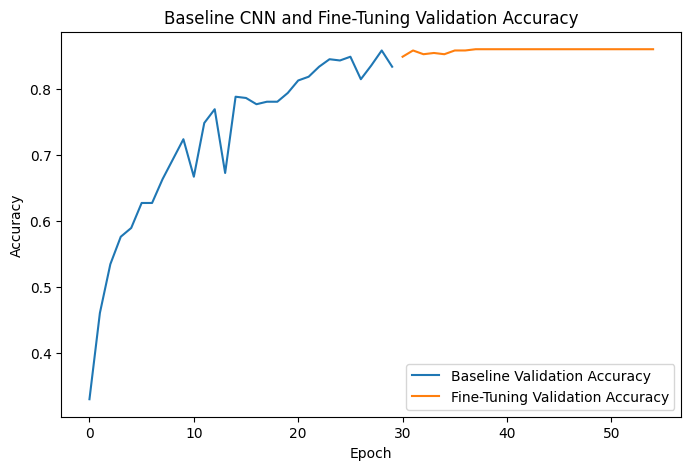

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stage1.history["val_accuracy"],
    label="Baseline Validation Accuracy"
)

plt.plot(
    range(
        len(history_stage1.history["val_accuracy"]),
        len(history_stage1.history["val_accuracy"])
        + len(history_stage2.history["val_accuracy"])
    ),
    history_stage2.history["val_accuracy"],
    label="Fine-Tuning Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN and Fine-Tuning Validation Accuracy")
plt.legend()
plt.show()

## Fine-Tuning Loss

The loss curves are used to compare the baseline training stage with the fine-tuning stage.

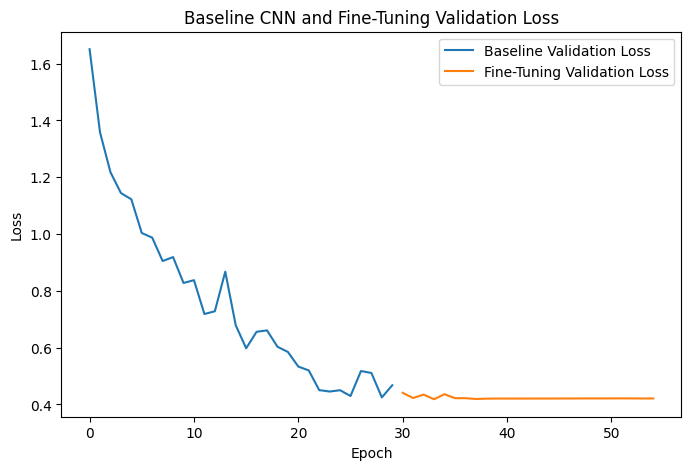

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stage1.history["val_loss"],
    label="Baseline Validation Loss"
)

plt.plot(
    range(
        len(history_stage1.history["val_loss"]),
        len(history_stage1.history["val_loss"])
        + len(history_stage2.history["val_loss"])
    ),
    history_stage2.history["val_loss"],
    label="Fine-Tuning Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN and Fine-Tuning Validation Loss")
plt.legend()
plt.show()

## Load Best Fine-Tuned Model

The fine-tuned model with the highest validation accuracy is loaded for final evaluation.

In [33]:
fine_tune_checkpoint_path = (
    "/kaggle/working/"
    "best_baseline_cnn_finetuned.keras"
)

model = tf.keras.models.load_model(
    fine_tune_checkpoint_path
)

print("Best fine-tuned model loaded successfully.")

Best fine-tuned model loaded successfully.


## Final Model Evaluation

The final fine-tuned CNN is evaluated on the validation dataset.

In [34]:
final_loss, final_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(
    "Final Validation Loss:",
    round(final_loss, 4)
)

print(
    "Final Validation Accuracy:",
    round(final_accuracy * 100, 2),
    "%"
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.8598 - loss: 0.4191
Final Validation Loss: 0.4191
Final Validation Accuracy: 85.98 %


In [35]:
true_labels = np.concatenate(
    [
        labels.numpy()
        for images, labels in val_ds
    ]
)

predictions = model.predict(
    val_ds,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(
    classification_report(
        true_labels,
        predicted_classes,
        target_names=class_names,
        digits=4
    )
)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
                       precision    recall  f1-score   support

bacterial_leaf_blight     0.8485    0.9545    0.8984        88
           brown_spot     0.7245    0.8068    0.7634        88
              healthy     0.9600    0.8182    0.8834        88
           leaf_blast     0.7750    0.7045    0.7381        88
           leaf_scald     0.9878    0.9205    0.9529        88
    narrow_brown_spot     0.8936    0.9545    0.9231        88

             accuracy                         0.8598       528
            macro avg     0.8649    0.8598    0.8599       528
         weighted avg     0.8649    0.8598    0.8599       528



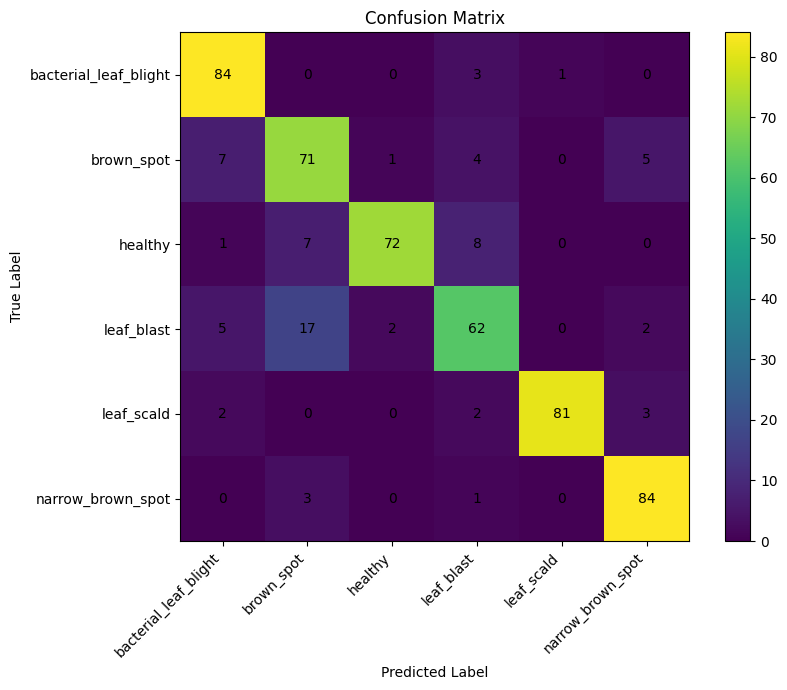

In [36]:
cm = confusion_matrix(
    true_labels,
    predicted_classes
)

plt.figure(figsize=(9, 7))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(
    len(class_names)
)

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [37]:
final_model_path = (
    "/kaggle/working/"
    "rice_leaf_baseline_cnn_final.keras"
)

model.save(
    final_model_path
)

print(
    "Final model saved:"
)

print(final_model_path)

Final model saved:
/kaggle/working/rice_leaf_baseline_cnn_final.keras


## Single Image Prediction

This section can be used to test one rice leaf image by providing its file path.

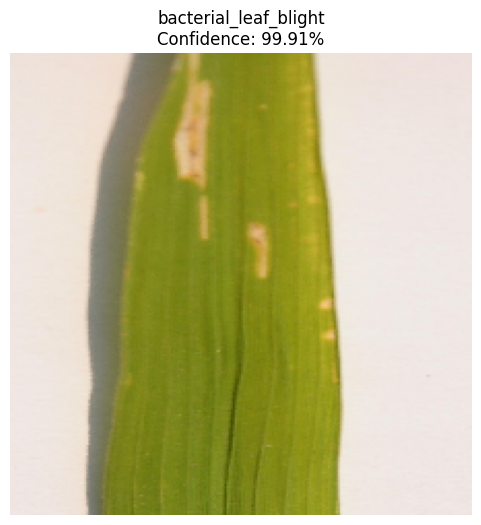

Predicted Class: bacterial_leaf_blight
Confidence: 99.91%


In [38]:
image_path = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation/bacterial_leaf_blight/bacterial_val (11).JPG"

image = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = tf.expand_dims(
    image_array,
    axis=0
)

prediction = model.predict(
    image_array,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

predicted_class = class_names[
    predicted_index
]

confidence = prediction[0][
    predicted_index
] * 100

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"{predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")